# pytm30 Tutorial - the Dead Simple Version

This notebook teaches you how to use **pytm30** to compute [ANSI/IES TM-30-20](https://www.ies.org/) color-rendition metrics for a light source, from Python.

**What is TM-30-20?** It's the modern replacement for the old CRI (Ra) number. Instead of one score, it gives you two independent numbers:

- **Rf** (fidelity) - how close colors look to a reference light source, 0–100 (higher = more accurate colors)
- **Rg** (gamut) - whether colors look more or less saturated than the reference, ~100 = neutral, above 100 = more vivid, below 100 = duller

No prior TM-30 knowledge assumed. Every cell is small, and explained before you run it.

## 0. Setup

Install pytm30 first, from the repo root (one directory up from this notebook):

```bash
pip install .
```

That builds the C++ core and Python bindings in one step and installs a
real, importable `tm30_calc` package - no separate build step, no
`PYTHONPATH` tricks. If the import below fails, that's the command to run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tm30_calc import TM30Calc, Cmf

print("Imports OK.")

Imports OK.


## 1. Your first evaluation

`TM30Calc` is the main entry point. Create **one** instance and reuse it - it loads the reference data tables (color-matching functions, reference color samples, etc.) once, up front, so every evaluation after that is fast. Don't create a new `TM30Calc()` per spectrum.

A "SPD" (Spectral Power Distribution) is just an array of 401 numbers: how much light energy a source emits at each 1 nm step from 380 nm to 780 nm (the visible spectrum). We'll start with the simplest possible SPD - equal energy at every wavelength - just to see the mechanics work.

In [2]:
calc = TM30Calc()  # loads tables once - create this ONCE, not per SPD

equal_energy_spd = np.full(401, 100.0)  # same power at every wavelength, 380-780nm

result = calc.eval(equal_energy_spd)

print(f"Rf  = {result.rf:.1f}")
print(f"Rg  = {result.rg:.1f}")
print(f"CCT = {result.cct:.0f} K")
print(f"Duv = {result.duv:.5f}")

Rf  = 94.7
Rg  = 103.7
CCT = 5455 K
Duv = -0.00442


## 2. What's in a result?

`calc.eval(...)` returns a `Tm30Result` object - think of it as a read-only bag of numbers. By default (nothing special passed), you always get these 9 fields:

| Field | What it is | Shape |
|---|---|---|
| `.rf` | Fidelity index, 0-100 | single number |
| `.rg` | Gamut index, ~100 = neutral | single number |
| `.cct` | Correlated Color Temperature (Kelvin) | single number |
| `.duv` | Distance from the Planckian (blackbody) locus | single number |
| `.delta_e_avg` | Average color difference across all 99 reference color samples | single number |
| `.rf_skin` | Fidelity specifically for skin tones | single number |
| `.rf_cesi` | Per-sample fidelity, one value per reference color sample | 99 values |
| `.rcs_hj` | Local chroma shift, per hue-angle bin | 16 values |
| `.rhs_hj` | Local hue shift, per hue-angle bin | 16 values |

In [3]:
print(
    "rf_cesi shape:", result.rf_cesi.shape, " (first 5 values:", result.rf_cesi[:5], ")"
)
print("rcs_hj  shape:", result.rcs_hj.shape)
print("rhs_hj  shape:", result.rhs_hj.shape)

rf_cesi shape: (99,)  (first 5 values: [97.12983709 95.36228285 94.20710953 95.8186125  93.93252834] )
rcs_hj  shape: (16,)
rhs_hj  shape: (16,)


## 3. A real light source, loaded from a file

pytm30 ships some real reference spectra in `data/` - standard illuminants and lamp types used throughout the lighting industry. Let's load a real one: **D65**, standard daylight.

Every SPD file here is just wavelength + value columns, 380-780 nm, 1 nm steps (401 rows).

In [25]:
# This notebook lives in notebooks/, so the data/ folder is one level up.
d65 = np.loadtxt("../data/d65_1nm.csv", delimiter=",", skiprows=1)
wavelengths = d65[:, 0]
d65_spd = d65[:, 1]

print(
    "Loaded", len(d65_spd), "points, from", wavelengths[0], "to", wavelengths[-1], "nm"
)

result_d65 = calc.eval(d65_spd)
print(
    f"D65 -> Rf={result_d65.rf:.1f}  Rg={result_d65.rg:.1f}  CCT={result_d65.cct:.0f} K"
)

Loaded 401 points, from 380.0 to 780.0 nm
D65 -> Rf=100.0  Rg=100.0  CCT=6502 K


While the default wavelength grid is pre-computed during construction, it can be overridden during runtime. Note, however, that this will recompute all needed reference spectra and sensitivity curves for the grid override leading to significant slowdowns. 

In [24]:
calc.eval(d65_spd[::3], wavelengths[::3])

Tm30Result(Rf=100.0, Rg=100.0, CCT=6503 K, Duv=0.003222)

D65 *is* one of TM-30's reference illuminants at its own CCT, so it should score close to perfect: Rf ≈ 100, Rg ≈ 100. That's expected - it's being checked against itself.

Now let's try something less ideal: **FL2**, a common fluorescent lamp.

In [6]:
fl2 = np.loadtxt("../data/fl2_1nm.csv", delimiter=",", skiprows=1)
fl2_spd = fl2[
    :, 1
]  # same wavelength grid as D65 (380-780nm, 1nm), so we can reuse `wavelengths`

result_fl2 = calc.eval(fl2_spd, wavelengths)
print(
    f"FL2 -> Rf={result_fl2.rf:.1f}  Rg={result_fl2.rg:.1f}  CCT={result_fl2.cct:.0f} K"
)
print(
    "\nFluorescent lamps typically render colors less faithfully than daylight -- notice Rf is lower."
)

FL2 -> Rf=70.2  Rg=86.4  CCT=4225 K

Fluorescent lamps typically render colors less faithfully than daylight -- notice Rf is lower.


## 4. Batch evaluation - many SPDs at once

If you have lots of spectra to evaluate, pass a 2-D array (shape `N × 401`) instead of looping - it's much faster than calling `eval()` once per spectrum, because the whole batch runs through the C++ pipeline in one call instead of N separate Python-level round trips.

Batch input returns a **single** `Tm30BatchResult`, not a list - every field is a numpy array with the batch as its leading axis, so `.rf` is shape `(N,)`, not N separate objects.

In [7]:
spd_batch = np.vstack([equal_energy_spd, d65_spd, fl2_spd])  # shape (3, 401)

batch_result = calc.eval(
    spd_batch, wavelengths
)  # ONE Tm30BatchResult -- .rf is a (3,) array

print("rf shape:", batch_result.rf.shape)
print("valid:", batch_result.valid)  # which rows passed validation

for name, rf, rg in zip(
    ["equal-energy", "D65", "FL2"], batch_result.rf, batch_result.rg
):
    print(f"{name:<14} Rf={rf:6.1f}  Rg={rg:6.1f}")

rf shape: (3,)
valid: [ True  True  True]
equal-energy   Rf=  94.7  Rg= 103.7
D65            Rf= 100.0  Rg= 100.0
FL2            Rf=  70.2  Rg=  86.4


In [8]:
batch_result.to_dataframe(arrays=True)

,rf,rg,cct,duv,delta_e_avg,rf_skin,valid,rcs_hj,rhs_hj,rf_cesi
0,94.713012,103.657595,5455.054394,-0.004419,0.785700,95.353189,True,"[0.017658683325340475, 0.00801032184708752, 0....","[0.00024516965646134134, 0.00693245748182878, ...","[97.1298370879886, 95.36228285255972, 94.20710..."
1,99.996783,99.999843,6501.848521,0.003215,0.000546,99.996803,True,"[-1.6491497661925624e-05, -1.2446420945104361e...","[-1.313271372679188e-05, -3.2922820609938538e-...","[99.99769266796663, 99.99509833229831, 99.9957..."
2,70.208265,86.438641,4225.137972,0.001863,4.428034,70.344754,True,"[-0.24877993384078137, -0.17618408255827347, -...","[-0.021886798072998724, 0.13970665592597345, 0...","[78.93146114540053, 59.076992751549035, 66.930..."


`arrays=True` gives you list-of-float columns, which is convenient but loses per-bin/per-sample structure. If you're migrating code that used to reformat `luxpy`'s TM-30 dicts into DataFrames (the `tm30_dict_to_dataframe()` helper some codebases use), pytm30 can produce the same kind of multi-level column layout, using luxpy's own top-level dict key names where a direct equivalent exists (`Rf`, `Rg`, `cct`, `duv`, `DEa`, `Rfi`, `Rcshj`, `Rhshj`, `Rfhj`, `DEhj`, `Sr`, `xyzt`, `xyzr`, `jabt`, `jabr`): per-sample fields get a `('Rfi', 'CES_01')…('Rfi', 'CES_99')` second column level, per-bin fields get `('Rcshj', 'bin_01')…('Rcshj', 'bin_16')`, and per-sample/bin `[X,Y,Z]`/`[J,a,b]` triples get a third level - so `df['Rfi']['CES_05']` and `df['xyzt']['CES_05']['X']` work exactly like they did against the old luxpy-based DataFrames. Fields with no direct luxpy top-level equivalent (`rf_skin`, the CVG plot coordinates, `hue_bin_index` - luxpy computes these differently, nested inside its own `hue_bin_data`) keep pytm30's own descriptive names.

In [9]:
mi_df = calc.eval(spd_batch, wavelengths, extras=True).to_dataframe(multiindex=True)

print("shape:", mi_df.shape)
print()
print("per-sample fidelity (luxpy name 'Rfi'), sample 5, all 3 SPDs:")
print(mi_df["Rfi"]["CES_05"])
print()
print("per-sample XYZ (luxpy name 'xyzt', extras=True), sample 5:")
print(mi_df["xyzt"]["CES_05"])

shape: (3, 1954)

per-sample fidelity (luxpy name 'Rfi'), sample 5, all 3 SPDs:
0    93.932528
1    99.994293
2    35.899199
Name: CES_05, dtype: float64

per-sample XYZ (luxpy name 'xyzt', extras=True), sample 5:
           X          Y          Z
0  21.930094  13.705694   9.868040
1  19.512825  12.728519  10.321184
2  18.507356  12.877742   7.109350


In [10]:
mi_df["Rfhj"]

,bin_01,bin_02,bin_03,bin_04,bin_05,bin_06,bin_07,bin_08,bin_09,bin_10,bin_11,bin_12,bin_13,bin_14,bin_15,bin_16
,,,,,,,,,,,,,,,,
0,95.298468,97.044350,95.252259,93.969508,92.984855,94.392910,93.866933,93.684604,94.719764,95.041971,96.458781,95.606604,94.718869,93.618040,92.804679,96.021735
1,99.995416,99.996836,99.996893,99.998613,99.997376,99.997449,99.996899,99.995211,99.996469,99.995944,99.997553,99.998448,99.997550,99.996101,99.995328,99.996076
2,60.282091,61.384735,52.678900,68.428206,79.643033,87.575659,76.848773,72.815253,76.234286,62.391683,69.711891,76.640233,81.398436,71.441045,63.650251,65.326275


## 5. `extras=False` vs `extras=True` - the important part

Everything above used the default settings. There's a second, much bigger set of fields pytm30 can give you - but only if you ask for it explicitly with `extras=True`.

**Why opt-in instead of always-on?** The default 9 fields from section 2 are small (~150 numbers per SPD). The `extras` fields add roughly **1,100 more numbers per SPD** - local per-bin fidelity, the actual plotting geometry for the Color Vector Graphic, per-sample colorimetry, and more. For *one* spectrum that's nothing. For a batch of 100,000 spectra, that's the difference between megabytes and gigabytes of numpy arrays - so pytm30 makes you ask for it, instead of always paying that cost by default.

First, let's see what happens if you try to use an `extras` field *without* asking for it:

In [11]:
plain_result = calc.eval(d65_spd, wavelengths)  # extras defaults to False

try:
    plain_result.cvg_x_test
except KeyError as e:
    print(f"KeyError: {e}")
    print("\nMakes sense -- we never asked for extras, so it's not there.")

KeyError: 'cvg_x_test'

Makes sense -- we never asked for extras, so it's not there.


In [12]:
plain_result.to_dataframe(arrays=True)

,rf,rg,cct,duv,delta_e_avg,rf_skin,rf_cesi,rcs_hj,rhs_hj
0,99.996783,99.999843,6501.848521,0.003215,0.000546,99.996803,"[99.99769266796663, 99.99509833229831, 99.9957...","[-1.6491497661925624e-05, -1.2446420945104361e...","[-1.313271372679188e-05, -3.2922820609938538e-..."


Now pass `extras=True`, and the same field works: the underlying C++ computes it either way, `extras` only controls whether it gets copied into the result you receive.

In [13]:
full_result = calc.eval(d65_spd, wavelengths, extras=True)

print("Now it works:")
print("cvg_x_test shape:", full_result.cvg_x_test.shape)
print("cvg_x_test values:", full_result.cvg_x_test)

Now it works:
cvg_x_test shape: (16,)
cvg_x_test values: [ 97.96664891  84.28433847  54.36040405  19.30563778  -7.23185606
 -52.04724009 -83.86724685 -99.23337404 -98.66316204 -85.18562472
 -55.84772034 -17.7751821   11.94334981  55.75121678  82.28111226
  98.54717004]


### What `extras=True` unlocks

| Field | What it is | Shape |
|---|---|---|
| `.rf_hj` | Local fidelity, per hue-angle bin | 16 values |
| `.de_hj` | Mean color difference (ΔE′), per hue-angle bin | 16 values |
| `.cvg_x_test`, `.cvg_y_test`, `.cvg_j_test` | Color Vector Graphic - test-source plot coordinates | 16 values each |
| `.cvg_x_ref`, `.cvg_y_ref`, `.cvg_j_ref` | Color Vector Graphic - reference-circle plot coordinates | 16 values each |
| `.reference_spd` | The reference illuminant's spectrum, resampled to your wavelength grid | matches your SPD's length |
| `.xyz_test_ces`, `.xyz_ref_ces` | Per-sample XYZ tristimulus values, under test / reference illuminant | (99, 3) each |
| `.jab_test_ces`, `.jab_ref_ces` | Per-sample CAM02-UCS [J′, a′, b′] coordinates, under test / reference illuminant | (99, 3) each |
| `.hue_bin_index` | Which of the 16 hue bins each of the 99 samples was assigned to | 99 values |

Everything in the "default 9" table from section 2 is *always* there too - `extras=True` only adds fields, it never removes any.

**Rule of thumb:** leave `extras=False` (the default) unless you're building a plot or doing sample-level diagnostics.

## 6. Bonus: plotting the actual TM-30 Color Vector Graphic

Now that we have the CVG coordinates, let's use them for what they're for: the classic TM-30 "flower" plot - a reference circle vs. the test source's actual color shifts around it. This is exactly why `extras=True` exists.

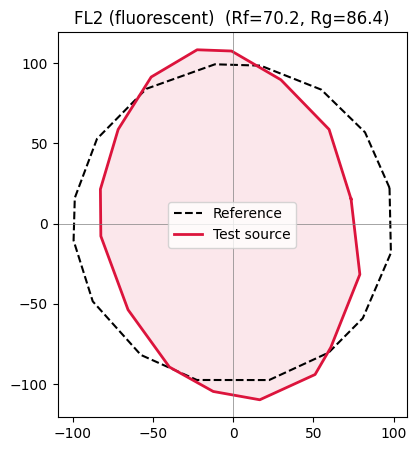

In [14]:
def plot_cvg(result, title):
    # close the polygon by repeating the first point at the end
    x_test = np.append(result.cvg_x_test, result.cvg_x_test[0])
    y_test = np.append(result.cvg_y_test, result.cvg_y_test[0])
    x_ref = np.append(result.cvg_x_ref, result.cvg_x_ref[0])
    y_ref = np.append(result.cvg_y_ref, result.cvg_y_ref[0])

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(x_ref, y_ref, color="black", linestyle="--", label="Reference")
    ax.plot(x_test, y_test, color="crimson", linewidth=2, label="Test source")
    ax.fill(x_test, y_test, color="crimson", alpha=0.1)
    ax.set_aspect("equal")
    ax.set_title(f"{title}  (Rf={result.rf:.1f}, Rg={result.rg:.1f})")
    ax.legend()
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    plt.show()


fl2_extras = calc.eval(fl2_spd, wavelengths, extras=True)
plot_cvg(fl2_extras, "FL2 (fluorescent)")

In [15]:
fl2_extras.to_dataframe(arrays=True)

,rf,rg,cct,duv,delta_e_avg,rf_skin,rf_cesi,rcs_hj,rhs_hj
0,70.208265,86.438641,4225.137972,0.001863,4.428034,70.344754,"[78.93146114540053, 59.076992751549035, 66.930...","[-0.24877993384078137, -0.17618408255827347, -...","[-0.021886798072998724, 0.13970665592597345, 0..."


## 7. Convenience: SPD → XYZ / Yuv

Two small helpers if all you want is the raw tristimulus values, without running the full TM-30 pipeline:

In [16]:
xyz = calc.spd_to_xyz(d65_spd, wavelengths)  # [X, Y, Z], normalized so Y=100
yuv = calc.spd_to_Yuv(d65_spd, wavelengths)  # [Y, u', v']  (CIE 1976)

print("D65 XYZ:", xyz)
print("D65 Yuv:", yuv)

D65 XYZ: [ 94.81064112 100.         107.30369299]
D65 Yuv: [100.           0.19786      0.46955173]


Three more small helpers round this out - same rule as above: each inherits this calculator's CMF/observer and wavelength grid, with an optional `cmf=` override for a single call when you need it.

### `xyz_to_Yuv` - convert XYZ you already have

If you already have XYZ tristimulus values from somewhere (e.g. `spd_to_xyz` above), this just does the coordinate conversion - no spectrum or CMF involved, so there's nothing to inherit or override here:

In [17]:
yuv_from_xyz = calc.xyz_to_Yuv(xyz)  # same `xyz` computed above

print("Same Yuv, computed directly from XYZ:", yuv_from_xyz)

Same Yuv, computed directly from XYZ: [100.           0.19786      0.46955173]


### `cct_to_xyz` - the reference illuminant's own XYZ, from a CCT alone

Every TM-30 evaluation internally builds a reference illuminant SPD for the test source's CCT (pure Planckian below 4000 K, pure CIE daylight above 5000 K, a proportional blend in between) and computes its XYZ. `cct_to_xyz` exposes that step directly - handy when you want "what would perfectly neutral light at this color temperature look like," without a real test spectrum. Pass a single CCT, or an array for a batch:

In [18]:
xyz_2700k = calc.cct_to_xyz(2700.0)  # warm, incandescent-like
xyz_6500k = calc.cct_to_xyz(6500.0)  # cool, daylight-like

print("2700 K reference XYZ:", xyz_2700k)
print("6500 K reference XYZ:", xyz_6500k)

# Batch: an array of CCTs in, one row of XYZ per CCT out
ccts = np.array([2700.0, 4000.0, 6500.0])
xyz_batch = calc.cct_to_xyz(ccts)
print("\nBatch shape:", xyz_batch.shape)
print(xyz_batch)

2700 K reference XYZ: [113.32783049 100.          31.13084384]
6500 K reference XYZ: [ 94.81245898 100.         107.2613117 ]

Batch shape: (3, 3)
[[113.32783049 100.          31.13084384]
 [101.79815354 100.          64.19627481]
 [ 94.81245898 100.         107.2613117 ]]


### `spd_to_power` - radiometric or photometric power

Total power of an SPD, in one of two units - picked with a plain boolean, not a string code like some other libraries use:

- `photometric=False` (the default) - **radiometric** power (watts): the raw spectral integral, no eye-response weighting at all.
- `photometric=True` - **photometric** power (lumens): weighted by the CIE luminous-efficiency function and scaled by Km = 683 lm/W.

`lambda_min`/`lambda_max` restrict the integration range, same as on `spd_to_xyz`.

In [19]:
radiometric = calc.spd_to_power(d65_spd, wavelengths)  # W, unweighted
photometric = calc.spd_to_power(d65_spd, wavelengths, photometric=True)  # lm

print(f"D65 radiometric power: {radiometric:.1f}")
print(f"D65 photometric power: {photometric:.1f}")

power_400_700 = calc.spd_to_power(
    d65_spd, wavelengths, lambda_min=400.0, lambda_max=700.0
)
print(f"D65 radiometric power, 400-700nm only: {power_400_700:.1f}")

D65 radiometric power: 35180.2
D65 photometric power: 7936694.5
D65 radiometric power, 400-700nm only: 28717.7


### One-off `cmf=` override

`spd_to_xyz`, `spd_to_Yuv`, `cct_to_xyz`, and `spd_to_power` all accept an optional `cmf=` for a single call, without changing the calculator's own bound observer (same `Cmf` enum / string / path as `TM30Calc(cmf=...)`):

In [20]:
xyz_default_cmf = calc.cct_to_xyz(6500.0)
xyz_1931_cmf = calc.cct_to_xyz(6500.0, cmf=Cmf.CIE_1931_2)  # just for this one call

print("Default CMF (1964 10 deg):     ", xyz_default_cmf)
print("CIE 1931 2 deg, this call only:", xyz_1931_cmf)

Default CMF (1964 10 deg):      [ 94.81245898 100.         107.2613117 ]
CIE 1931 2 deg, this call only: [ 95.04272696 100.         108.81586109]


## 8. Choosing a different color-matching-function observer

By default pytm30 uses the CIE 1964 10° observer (the TM-30-20 standard). You can swap it:

In [21]:
calc_1931 = TM30Calc(
    cmf=Cmf.CIE_1931_2
)  # 2-degree observer instead of the 10-degree default
result_1931 = calc_1931.eval(d65_spd, wavelengths)
print(
    f"With CIE 1931 2 degree observer: Rf={result_1931.rf:.1f}  Rg={result_1931.rg:.1f}"
)

With CIE 1931 2 degree observer: Rf=100.0  Rg=100.0


## Cheat sheet

- Create **one** `TM30Calc()` and reuse it - don't recreate it per SPD.
- `calc.eval(spd)` for a single 401-value spectrum → `Tm30Result` (scalar fields).
- `calc.eval(spd_matrix)` (shape N×401) for a batch → **one** `Tm30BatchResult` (every field is an `(N, ...)` array, not a list of N objects) - pass `wavelengths` explicitly if your grid isn't exactly 380-780nm @ 1nm.
- Default fields (always there): `rf, rg, cct, duv, delta_e_avg, rf_skin, rf_cesi, rcs_hj, rhs_hj`.
- Pass `extras=True` to also get: `rf_hj, de_hj, cvg_j/x/y_test, cvg_j/x/y_ref, reference_spd, xyz_test_ces, xyz_ref_ces, jab_test_ces, jab_ref_ces, hue_bin_index` - needed for plotting or sample-level diagnostics, skip it otherwise.
- `result.to_dataframe(multiindex=True)` for a luxpy-`tm30_dict_to_dataframe()`-compatible multi-level column layout (`CES_01..CES_99` / `bin_01..bin_16` / `X,Y,Z` or `J,a,b` sub-columns).
- `calc.spd_to_xyz(...)` / `calc.spd_to_Yuv(...)` if all you want is tristimulus values.
- `calc.xyz_to_Yuv(xyz)` if you already have XYZ and just need the Yuv conversion.
- `calc.cct_to_xyz(cct)` for the reference illuminant's own XYZ at a given CCT (scalar or array of CCTs) - no wavelengths= override, always uses this calculator's fixed grid.
- `calc.spd_to_power(spd, photometric=False)` for total power - radiometric (W) by default, photometric (lm) with `photometric=True`.
- `cmf=...` works as a one-off override on `spd_to_xyz`, `spd_to_Yuv`, `cct_to_xyz`, and `spd_to_power` too, without changing the calculator's own bound observer.
- `TM30Calc(cmf=Cmf.CIE_1931_2)` (or any `Cmf` member) to change the observer for the whole calculator.